In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import tqdm
import matplotlib.pyplot as plt

import cmasher as cmr
import numpy as np
import pickle
from scipy.stats import pearsonr

from utils.misc.results_saving import save_results, load_results, load_results_for_model_and_revisions, load_all_results
from utils.model_definitions.text_automodel_wrapper import TextModelSpecifications

plt.rcParams.update({'font.size': 14})

In [2]:
all_results = load_all_results(should_normalize_scores_across_models=False, base_path='results')

# Single Model, Average Metric vs Average Main Score for each layer

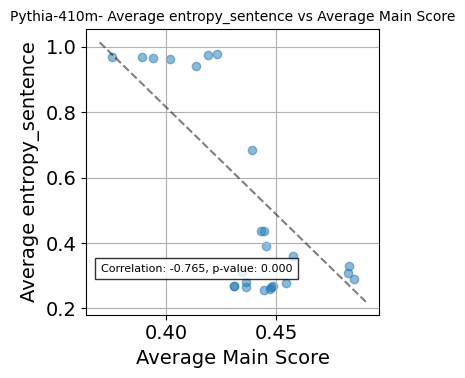

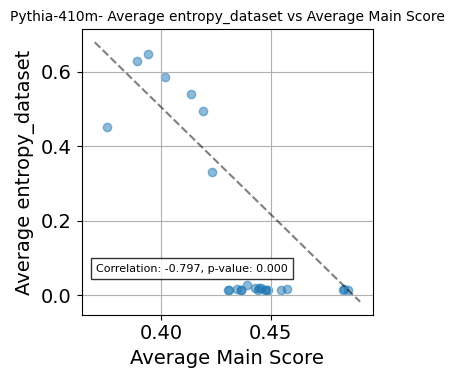

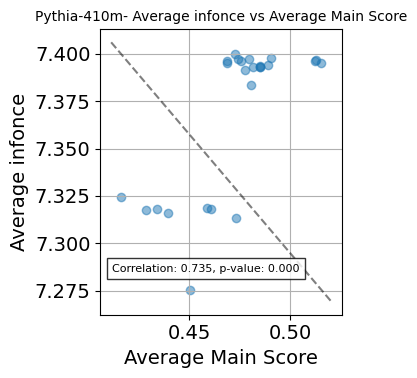

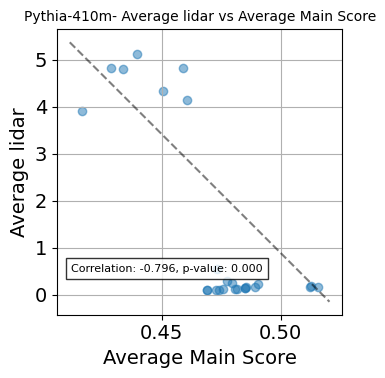

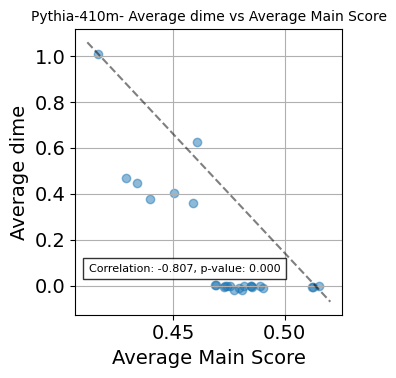

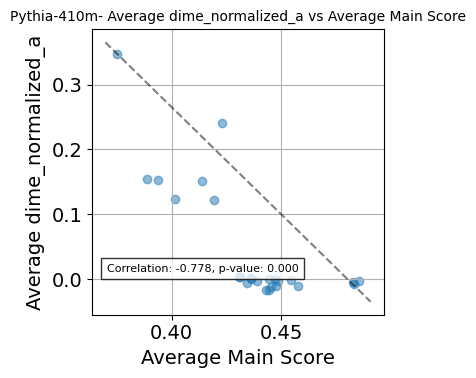

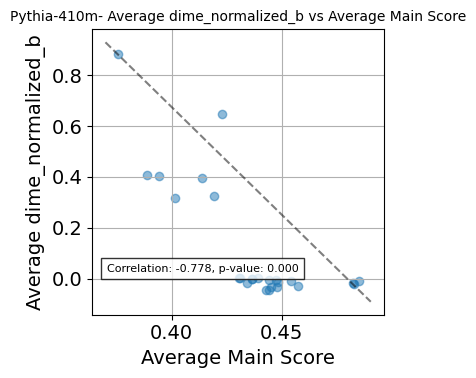

In [3]:
METRICS_CHOICES = ['entropy_sentence', 
           'entropy_dataset',
           'infonce',
           'lidar',
           'dime',
           'dime_normalized_a',
           'dime_normalized_b']

model_specs = TextModelSpecifications(
    model_family='Pythia',
    model_size='410m',
    revision='main'
)

for METRIC_TO_PLOT in METRICS_CHOICES:
    x_values = []  # Main scores
    y_values = []  # Entropy values
    for layer in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
            
        layer_results = all_results[model_specs.model_family][model_specs.model_size]['main'][layer]
        
        # Calculate average main score for this layer
        main_scores = []
        metric_values = []
        for task_name, task_results in layer_results.items():
            try:
                main_scores.append(task_results['main_score'])
                
                if METRIC_TO_PLOT == 'entropy_sentence':
                    metric_values.append(task_results['entropy_sentence']['maxEntropy'])
                elif METRIC_TO_PLOT == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif METRIC_TO_PLOT == 'infonce':
                    metric_values.append(task_results['infonce']['raw'])
                elif METRIC_TO_PLOT == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                elif METRIC_TO_PLOT == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif METRIC_TO_PLOT == 'dime_normalized_a':
                    metric_values.append(task_results['dime']['logD'] / task_results['entropy_sentence']['logD'])
                elif METRIC_TO_PLOT == 'dime_normalized_b':
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_sentence']['maxEntropy'])

            except KeyError as e:
                #print(f"KeyError for task {task_name} in layer {layer}", e)
                main_scores.remove(main_scores[-1])
                continue
                
        if main_scores:
            x_values.append(np.mean(main_scores))
            y_values.append(np.mean(metric_values))

    # Create square scatter plot
    plt.figure(figsize=(4, 4))
    plt.scatter(x_values, y_values, alpha=0.5)
    plt.xlabel('Average Main Score')
    plt.ylabel(f'Average {METRIC_TO_PLOT}')
    plt.title(f'{model_specs.model_family}-{model_specs.model_size}- Average {METRIC_TO_PLOT} vs Average Main Score', fontsize=10)
    plt.grid(True)

    # Calculate and display correlation coefficient
    correlation, p_value = pearsonr(x_values, y_values)
    plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}, p-value: {p_value:.3f}', 
             transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8), fontsize=8)

    # Add negative diagonal line
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Single Layer, Metric vs Main Score for each task

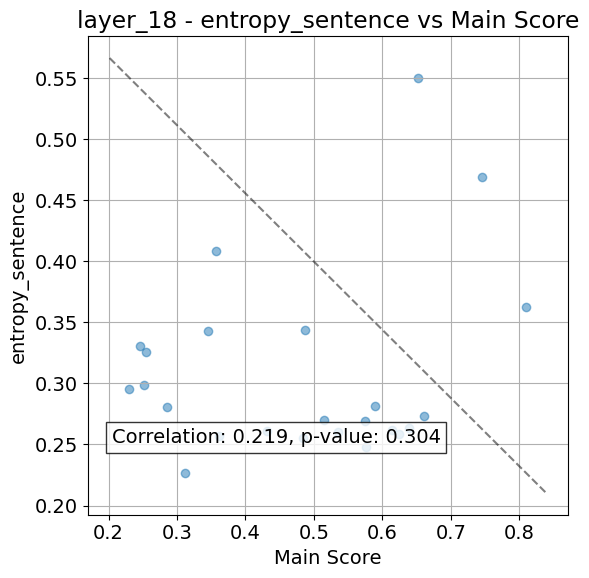

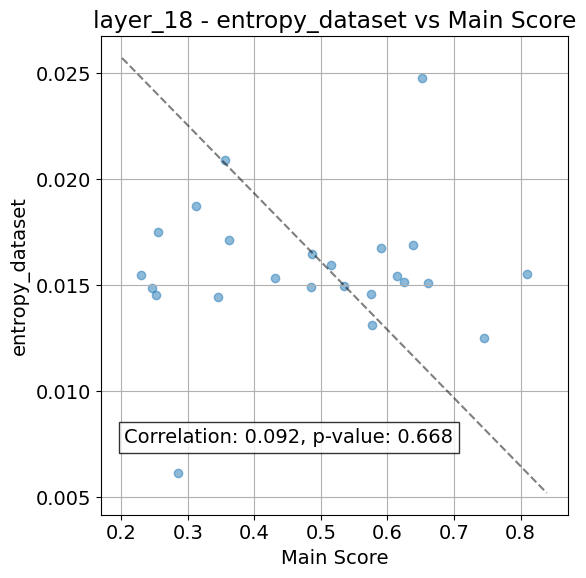

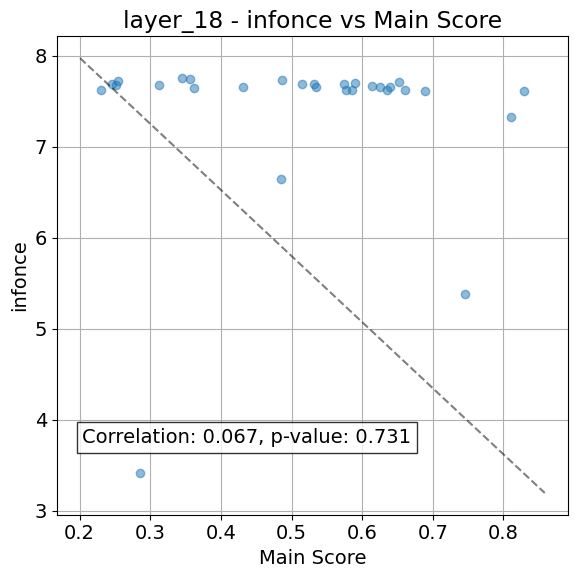

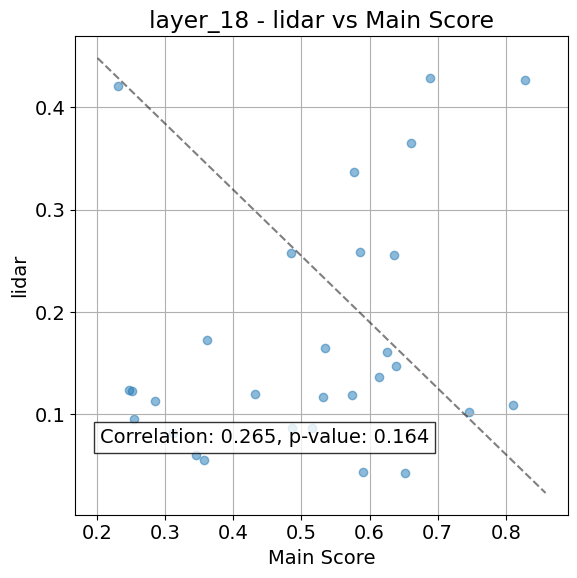

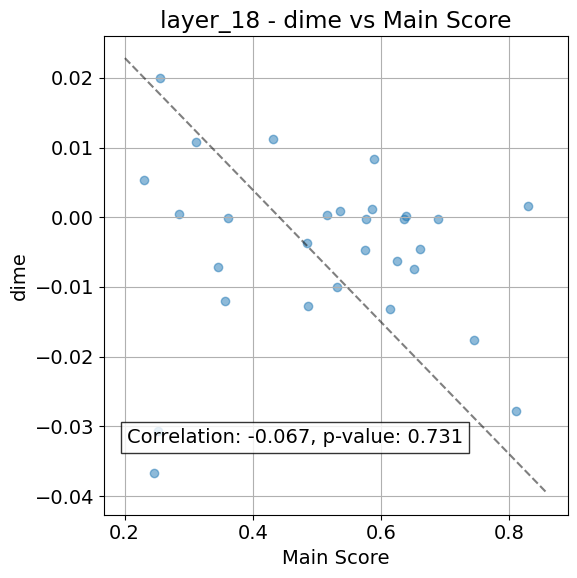

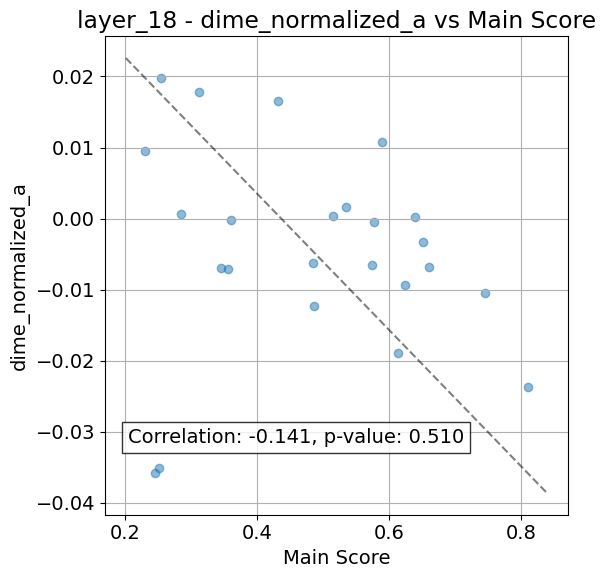

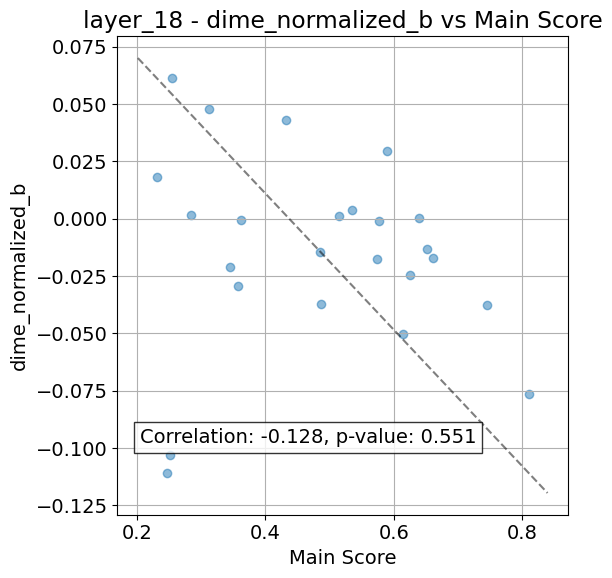

In [78]:
METRICS_CHOICES = ['entropy_sentence', 
           'entropy_dataset',
           'infonce',
           'lidar',
           'dime',
           'dime_normalized_a',
           'dime_normalized_b']
LAYER_TO_PLOT = 'layer_18'

model_specs = TextModelSpecifications(
    model_family='Pythia',
    model_size='410m',
    revision='main'
)

for METRIC_TO_PLOT in METRICS_CHOICES:
    main_scores = []
    metric_values = []

    for layer in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
        if layer != LAYER_TO_PLOT:
            continue
            
        layer_results = all_results[model_specs.model_family][model_specs.model_size]['main'][layer]
        for task_name, task_results in layer_results.items():
            try:
                main_scores.append(task_results['main_score'])
                
                if METRIC_TO_PLOT == 'entropy_sentence':
                    metric_values.append(task_results['entropy_sentence']['maxEntropy'])
                elif METRIC_TO_PLOT == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif METRIC_TO_PLOT == 'infonce':
                    metric_values.append(task_results['infonce']['raw'])
                elif METRIC_TO_PLOT == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                elif METRIC_TO_PLOT == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif METRIC_TO_PLOT == 'dime_normalized_a':
                    metric_values.append(task_results['dime']['logD'] / task_results['entropy_sentence']['logD'])
                elif METRIC_TO_PLOT == 'dime_normalized_b':
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_sentence']['maxEntropy'])

            except KeyError as e:
                #print(f"KeyError for task {task_name} in layer {layer}", e)
                main_scores.remove(main_scores[-1])
                continue

    # Create square scatter plot
    plt.figure(figsize=(6, 6))
    plt.scatter(main_scores, metric_values, alpha=0.5)
    plt.xlabel('Main Score')
    plt.ylabel(f'{METRIC_TO_PLOT}')
    plt.title(f'{LAYER_TO_PLOT} - {METRIC_TO_PLOT} vs Main Score')
    plt.grid(True)

    # Calculate and display correlation coefficient
    correlation, p_value = pearsonr(main_scores, metric_values)
    plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}, p-value: {p_value:.3f}', 
             transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8))

    # Add negative diagonal line
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Main Score Across Layers

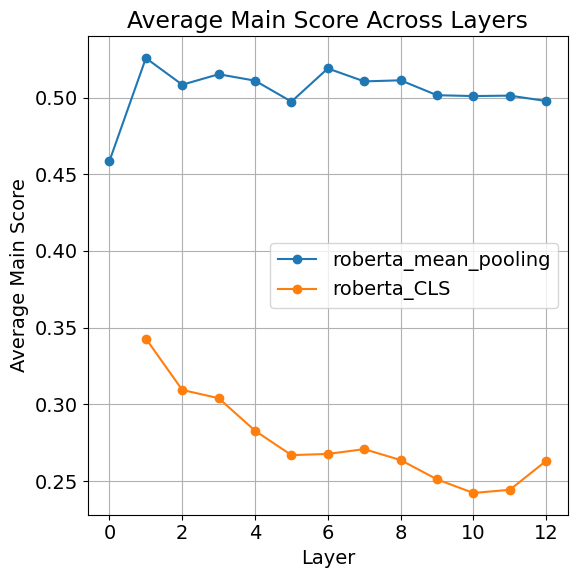

In [40]:
# plot roberta base main score across layers

specs_list = [
    TextModelSpecifications(
        model_family='roberta_mean_pooling',
        model_size='base',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='roberta_CLS',
        model_size='base',
        revision='main',
        ignore_checks=True
    )
]

plt.figure(figsize=(6, 6))

for specs in specs_list:    
    average_main_scores = []
    layer_nums = []
    
    for layer in all_results[specs.model_family][specs.model_size]['main'].keys():
        if not layer.startswith('layer_') or '_last' in layer:
            continue
            
        layer_num = int(layer.split('_')[1])
        layer_nums.append(layer_num)
        
        layer_results = all_results[specs.model_family][specs.model_size]['main'][layer]
        main_scores = []

        for task_name, task_results in layer_results.items():
            main_scores.append(task_results['main_score'])

        average_main_scores.append(np.mean(main_scores))

    # Sort by layer number
    sorted_indices = np.argsort(layer_nums)
    layer_nums = np.array(layer_nums)[sorted_indices]
    average_main_scores = np.array(average_main_scores)[sorted_indices]
    
    plt.plot(layer_nums, average_main_scores, marker='o', label=specs.model_family)

plt.xlabel('Layer')
plt.ylabel('Average Main Score')
plt.title('Average Main Score Across Layers')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Metric Across Layers

In [57]:
all_results['mamba']['370m']['main']['layer_0']['wikitext'].keys()

dict_keys(['entropy_dataset', 'dime', 'lidar', 'entropy_sentence', 'infonce'])

In [66]:
[all_results['Pythia']['410m']['main'][f'layer_{x}']['wikitext']['dime']['logD'] for x in range(24)]


[0.1605071667546744,
 0.037475213654280894,
 0.04980027287452329,
 0.04746778609962719,
 0.04173965933465265,
 0.04744426575166441,
 -0.004155612272868196,
 -0.0009659239494001455,
 0.00012735537628685048,
 0.0003717801326636172,
 0.00024021016785784083,
 0.00016786569241179685,
 6.926082063853418e-05,
 0.00016837322802303094,
 -0.0010418918410737877,
 -8.335758920380267e-05,
 -6.018491534575954e-05,
 9.024462976927624e-05,
 -0.0005403349529415399,
 -0.0008938056042722338,
 -0.0016862778404341991,
 -0.002764863523454758,
 -0.004152171625087989,
 -0.00491893661309608]

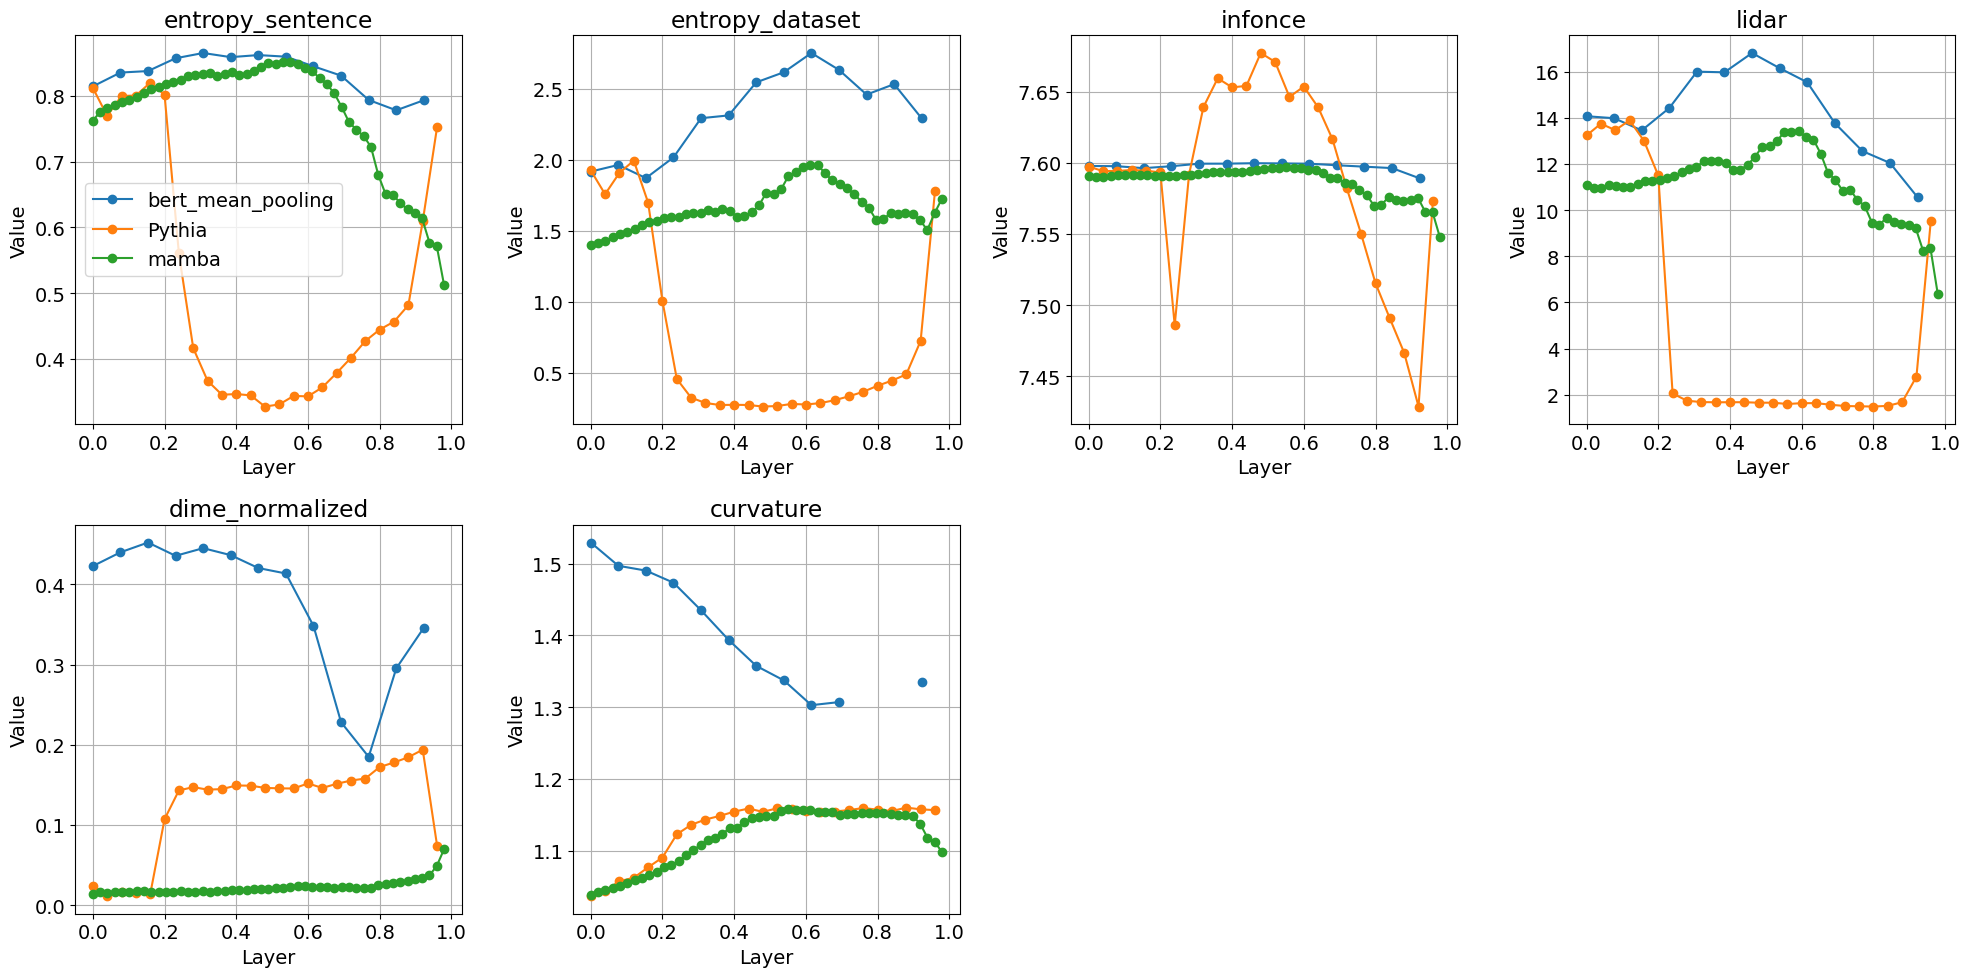

In [15]:
# plot metrics across layers

specs_list = [
    TextModelSpecifications(
        model_family='bert_mean_pooling',
        model_size='base',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='Pythia',
        model_size='410m',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='mamba',
        model_size='370m',
        revision='main',
        ignore_checks=True
    ),
]

metrics = ['entropy_sentence', 'entropy_dataset', 'infonce', 'lidar', 'dime_normalized', 'curvature']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for metric_idx, metric in enumerate(metrics):
    ax = axes[metric_idx]
    
    for specs in specs_list:    
        model_metric_values = []
        layer_nums = []
        
        for layer in all_results[specs.model_family][specs.model_size]['main'].keys():
            if not layer.startswith('layer_') or '_last' in layer:
                continue
                
            layer_num = int(layer.split('_')[1])
            layer_nums.append(layer_num)
            
            layer_results = all_results[specs.model_family][specs.model_size]['main'][layer]
            metric_values = []

            for task_name, task_results in layer_results.items():
                if task_name != 'wikitext':
                    continue
                if metric != 'dime_normalized' and metric not in task_results:
                    continue
                if metric == 'entropy_sentence':
                    metric_values.append(task_results['entropy_sentence']['maxEntropy'])
                elif metric == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif metric == 'infonce':
                    metric_values.append(task_results['infonce']['raw'])
                elif metric == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                elif metric == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif metric == 'dime_normalized':
                    if 'entropy_sentence' not in task_results:
                        continue
                    metric_values.append(task_results['dime']['maxEntropy'] / task_results['entropy_sentence']['raw'])
                elif metric == 'average_main_score':
                    metric_values.append(task_results['main_score'])
                elif metric == 'curvature':
                    metric_values.append(task_results['curvature']['raw'])

            model_metric_values.append(np.mean(metric_values))
        
        depth_percentages = [x / len(layer_nums) for x in layer_nums]
        ax.plot(depth_percentages, model_metric_values, marker='o', label=specs.model_family)
        
    ax.set_xlabel('Layer')
    ax.set_ylabel('Value')
    ax.set_title(f'{metric}')
    ax.grid(True)

    if metric == 'entropy_sentence':
        ax.legend()

# hide unused axes
for ax in axes:
    if ax.get_title() not in metrics:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

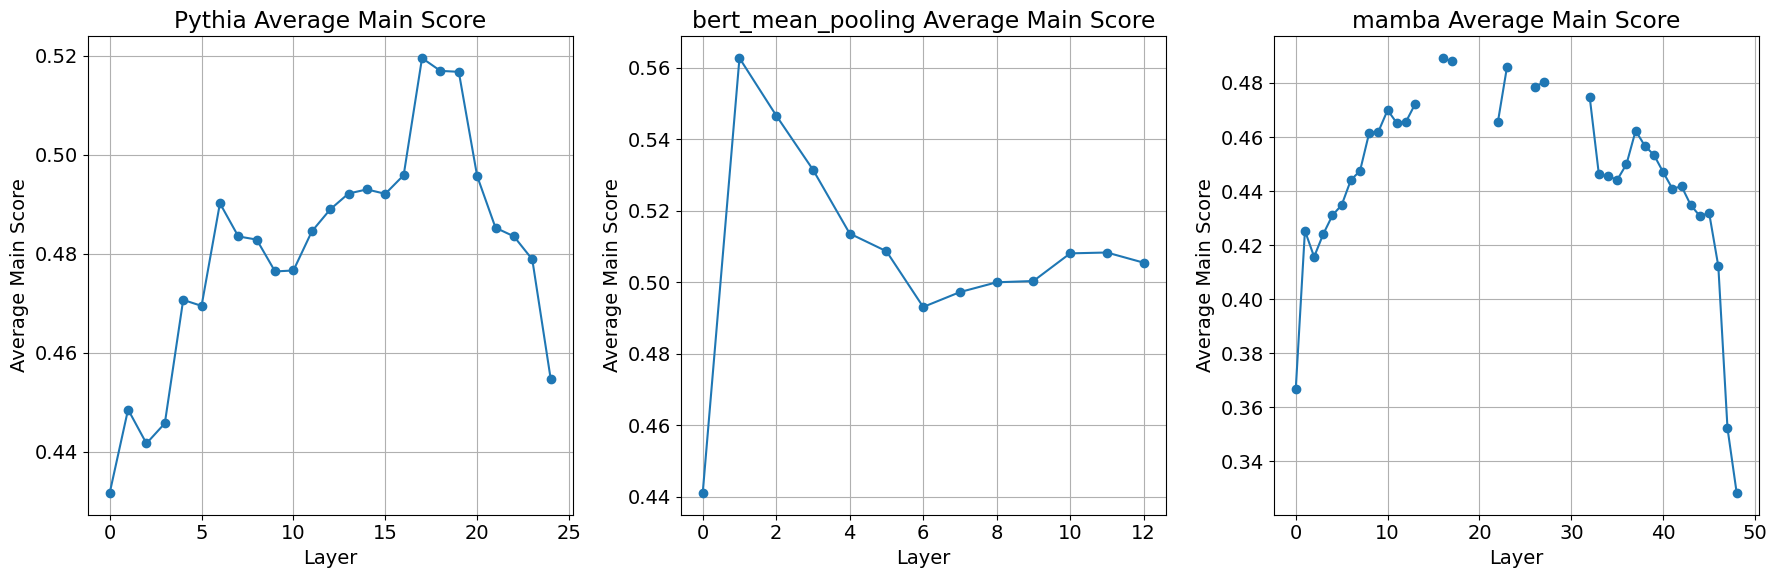

In [14]:
# plot roberta base main score across layers

specs_list = [
    TextModelSpecifications(
        model_family='Pythia',
        model_size='410m',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='bert_mean_pooling',
        model_size='base',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='mamba',
        model_size='370m',
        revision='main',
        ignore_checks=True
    )
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, specs in enumerate(specs_list):    
    average_main_scores = []
    layer_nums = []
    
    for layer in all_results[specs.model_family][specs.model_size]['main'].keys():
        if not layer.startswith('layer_') or '_last' in layer:
            continue
        
        layer_num = int(layer.split('_')[1])
        layer_nums.append(layer_num)
        
        layer_results = all_results[specs.model_family][specs.model_size]['main'][layer]
        main_scores = []

        for task_name, task_results in layer_results.items():
            if task_name == 'wikitext':
                continue
            main_scores.append(task_results['main_score'])

        if len(main_scores) > 5:
            average_main_scores.append(np.mean(main_scores))
        else:
            average_main_scores.append(np.nan)

    # Sort by layer number
    sorted_indices = np.argsort(layer_nums)
    layer_nums = np.array(layer_nums)[sorted_indices]
    average_main_scores = np.array(average_main_scores)[sorted_indices]
    
    axes[i].plot(layer_nums, average_main_scores, marker='o')
    axes[i].set_xlabel('Layer')
    axes[i].set_ylabel('Average Main Score')
    axes[i].set_title(f'{specs.model_family} Average Main Score')
    axes[i].grid(True)

plt.tight_layout()
plt.show()
